# KNN Dígitos — Análisis de Resultados
**Fuente:** `results_knn_v{i}.csv`  
**Métricas:** Speedup · Eficiencia · Granularidad · FLOPs/s · Ley de Amdahl · Tabla resumen

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.2,
    'lines.markersize': 8,
})

P_COLORS  = {1:'#888888', 2:'#e6194b', 4:'#3cb44b', 8:'#4363d8'}
P_MARKERS = {1:'o', 2:'s', 4:'^', 8:'D'}
P_VALS    = [1, 2, 4, 8]

# ── Helper: eje x con etiquetas 2⁰ 2¹ 2² 2³ ─────────────────────
SUP = str.maketrans('0123456789', '⁰¹²³⁴⁵⁶⁷⁸⁹')
def pow2_labels(vals):
    """['2⁰','2¹','2²','2³'] para [1,2,4,8]"""
    exps = {1:0, 2:1, 4:2, 8:3, 16:4, 32:5, 64:6, 128:7}
    return [f'2{str(exps.get(v,"?")).translate(SUP)}' for v in vals]

def set_p_xticks(ax, vals=P_VALS):
    """Eje x con escala log₂ pero etiquetas 2^k."""
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(mticker.NullFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xticks(vals)
    ax.set_xticklabels(pow2_labels(vals))

CSV_PATH = 'results_knn_v/results_knn_v1.csv'
print(f'Leyendo: {CSV_PATH}')
print('Ejemplo etiquetas p:', pow2_labels(P_VALS))

Leyendo: results_knn_v/results_knn_v1.csv
Ejemplo etiquetas p: ['2⁰', '2¹', '2²', '2³']


## 1. Carga y exploración

In [57]:
df = pd.read_csv(CSV_PATH)
print(f'Filas: {len(df)}   Columnas: {list(df.columns)}')
df.head(8)

Filas: 100   Columnas: ['version', 'it', 'n', 'p', 'n_train', 'n_test', 'k', 't_total', 't_compute', 't_comm', 't_bcast', 't_scatter', 't_gather', 'accuracy', 'flops', 'flops_per_sec']


,version,it,n,p,n_train,n_test,k,t_total,t_compute,t_comm,t_bcast,t_scatter,t_gather,accuracy,flops,flops_per_sec
0,v1,1,1797,1,1437,360,3,0.6716,0.6707,0.0009,0.0006,0.0000,0.0003,0.9861,99842760,"148,866,087.5400"
1,v1,2,1797,1,1437,360,3,0.6833,0.6824,0.0009,0.0006,0.0000,0.0003,0.9861,99842760,"146,311,097.8000"
2,v1,3,1797,1,1437,360,3,0.6939,0.6929,0.0009,0.0006,0.0000,0.0003,0.9861,99842760,"144,089,216.5400"
3,v1,4,1797,1,1437,360,3,0.6936,0.6927,0.0009,0.0006,0.0000,0.0003,0.9861,99842760,"144,138,422.0700"
4,v1,5,1797,1,1437,360,3,0.6877,0.6868,0.0010,0.0006,0.0000,0.0003,0.9861,99842760,"145,384,195.3400"
5,v1,1,1797,2,1437,360,3,0.3497,0.3485,0.0011,0.0009,0.0000,0.0002,0.9861,99842760,"286,485,541.2900"
6,v1,2,1797,2,1437,360,3,0.3485,0.3444,0.0041,0.0010,0.0000,0.0031,0.9861,99842760,"289,891,673.1700"
7,v1,3,1797,2,1437,360,3,0.3514,0.3502,0.0012,0.0009,0.0000,0.0002,0.9861,99842760,"285,068,372.9300"


In [58]:
print('Combinaciones (p, n):')
print(df.groupby(['p','n']).size().rename('runs').to_string())

Combinaciones (p, n):
p  n    
1  1797     5
   5000     5
   10000    5
   15000    5
   20000    5
2  1797     5
   5000     5
   10000    5
   15000    5
   20000    5
4  1797     5
   5000     5
   10000    5
   15000    5
   20000    5
8  1797     5
   5000     5
   10000    5
   15000    5
   20000    5


Filtramos outliers por IQR dentro de cada grupo `(n, p)`.

In [59]:
Q1  = df.groupby(['n','p'])['t_total'].transform(lambda x: x.quantile(0.25))
Q3  = df.groupby(['n','p'])['t_total'].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1
mask_out = (df['t_total'] >= Q1 - 1.5*IQR) & (df['t_total'] <= Q3 + 1.5*IQR)
print(f'Outliers removidos: {(~mask_out).sum()}  |  Filas restantes: {mask_out.sum()}')
df = df[mask_out].copy()

Outliers removidos: 12  |  Filas restantes: 88


In [60]:
AGG = df.groupby(['p','n']).agg(
    t_total_mean   = ('t_total',       'mean'),
    t_total_std    = ('t_total',       'std'),
    t_compute_mean = ('t_compute',     'mean'),
    t_compute_std  = ('t_compute',     'std'),
    t_comm_mean    = ('t_comm',        'mean'),
    t_comm_std     = ('t_comm',        'std'),
    t_bcast_mean   = ('t_bcast',       'mean'),
    t_scatter_mean = ('t_scatter',     'mean'),
    t_gather_mean  = ('t_gather',      'mean'),
    accuracy_mean  = ('accuracy',      'mean'),
    flops          = ('flops',         'first'),
    fps_mean       = ('flops_per_sec', 'mean'),
    fps_std        = ('flops_per_sec', 'std'),
).reset_index()

N_SIZES = sorted(df['n'].unique())
N_BASE  = N_SIZES[0]
N_MAX   = N_SIZES[-1]   # n más grande — usado en el ajuste teórico
print(f'Tamaños: {N_SIZES}')
print(f'N_BASE={N_BASE}   N_MAX={N_MAX} (usado en ajuste teórico)')
AGG[AGG.n == N_BASE]

Tamaños: [np.int64(1797), np.int64(5000), np.int64(10000), np.int64(15000), np.int64(20000)]
N_BASE=1797   N_MAX=20000 (usado en ajuste teórico)


,p,n,t_total_mean,t_total_std,t_compute_mean,t_compute_std,t_comm_mean,t_comm_std,t_bcast_mean,t_scatter_mean,t_gather_mean,accuracy_mean,flops,fps_mean,fps_std
0,1,1797,0.6860,0.0092,0.6851,0.0092,0.0009,0.0000,0.0006,0.0000,0.0003,0.9861,99842760,"145,757,803.8580","1,969,373.3757"
5,2,1797,0.3493,0.0017,0.3474,0.0025,0.0019,0.0015,0.0009,0.0000,0.0009,0.9861,99842760,"287,413,017.9825","2,092,119.6710"
10,4,1797,0.1793,0.0013,0.1755,0.0047,0.0038,0.0034,0.0011,0.0001,0.0027,0.9861,99842760,"569,214,064.4575","15,351,978.3821"
15,8,1797,0.0944,0.0018,0.0898,0.0024,0.0046,0.0021,0.0033,0.0001,0.0012,0.9861,99842760,"1,112,800,733.6240","31,355,340.1258"


## Paleta por n

In [61]:
import matplotlib.cm as cm
N_CMAP    = cm.get_cmap('viridis', len(N_SIZES))
N_COLORS  = {n: N_CMAP(i) for i, n in enumerate(N_SIZES)}
N_MARKERS = {n: m for n, m in zip(N_SIZES, ['o','s','^','D','P'])}
N_LABELS  = {n: f'n = {n:,}' for n in N_SIZES}
for n in N_SIZES:
    print(f'  {N_LABELS[n]}   marker={N_MARKERS[n]}')

  n = 1,797   marker=o
  n = 5,000   marker=s
  n = 10,000   marker=^
  n = 15,000   marker=D
  n = 20,000   marker=P


## 2. Speedup y Eficiencia — una línea por N
$$S(p,n)=\frac{T(1,n)}{T(p,n)} \qquad E(p,n)=\frac{S(p,n)}{p}$$
Eje x: escala log₂, etiquetas 2⁰ 2¹ 2² 2³. Eje y: lineal.

In [62]:
records = []
for n_val in N_SIZES:
    T1 = AGG.loc[(AGG.p==1)&(AGG.n==n_val),'t_total_mean']
    if T1.empty: continue
    sub = AGG[AGG.n==n_val].copy()
    sub['speedup']    = T1.values[0] / sub['t_total_mean']
    sub['efficiency'] = sub['speedup'] / sub['p']
    records.append(sub)
SP = pd.concat(records, ignore_index=True)
SP[['n','p','speedup','efficiency']].round(4)

,n,p,speedup,efficiency
0,1797,1,1.0000,1.0000
1,1797,2,1.9641,0.9820
2,1797,4,3.8255,0.9564
3,1797,8,7.2664,0.9083
4,5000,1,1.0000,1.0000
5,5000,2,1.9828,0.9914
6,5000,4,3.7964,0.9491
7,5000,8,7.4817,0.9352
8,10000,1,1.0000,1.0000
9,10000,2,1.9798,0.9899


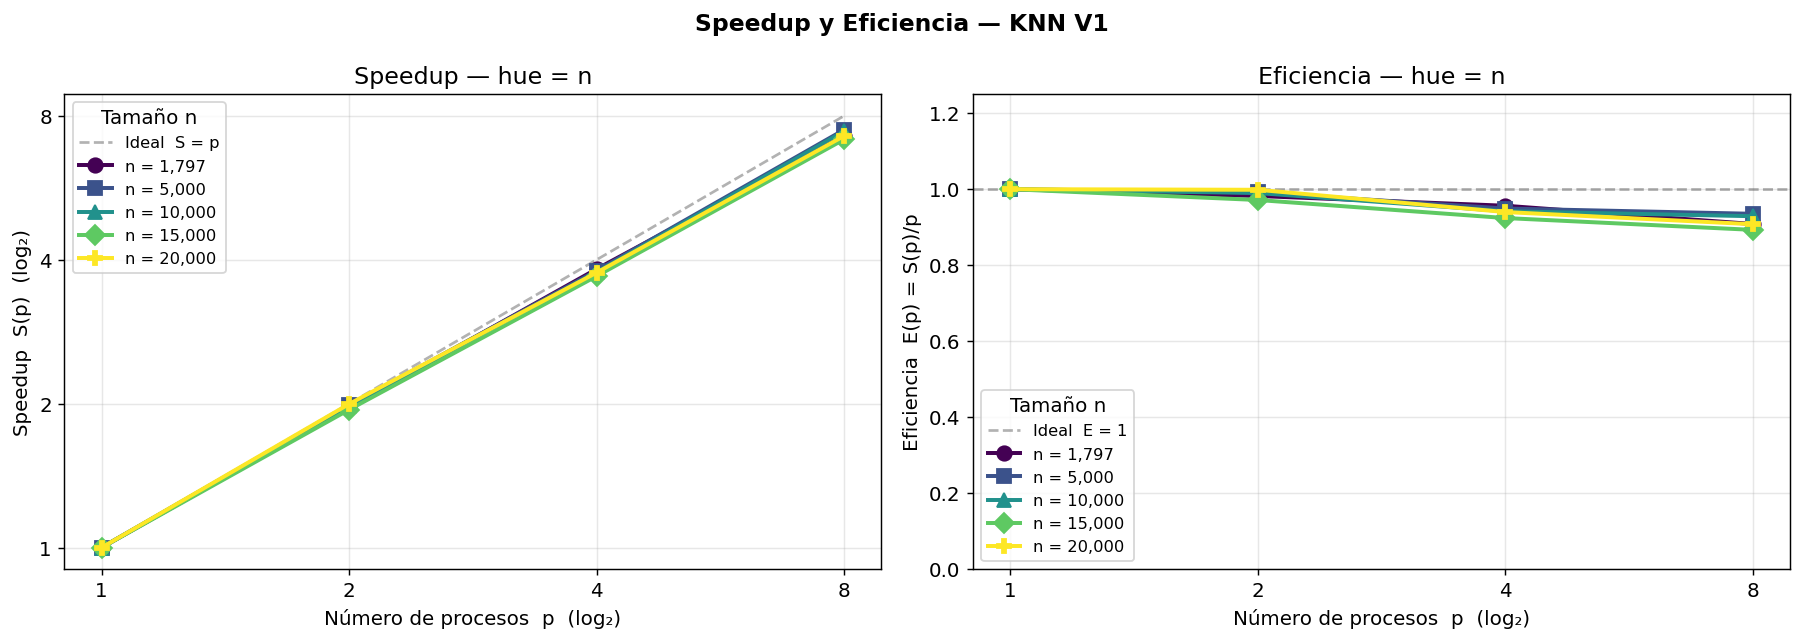

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Speedup ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(P_VALS, P_VALS, 'k--', alpha=0.3, lw=1.5, label='Ideal  S = p')
for n_val in N_SIZES:
    sub = SP[SP.n==n_val].sort_values('p')
    if sub.empty: continue
    ax.plot(sub['p'], sub['speedup'],
            f"{N_MARKERS[n_val]}-", color=N_COLORS[n_val], label=N_LABELS[n_val])

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(P_VALS); ax.set_xticklabels(P_VALS)
ax.set_yticks(P_VALS); ax.set_yticklabels(P_VALS)
ax.set_xlabel('Número de procesos  p  (log₂)')
ax.set_ylabel('Speedup  S(p)  (log₂)')
ax.set_title('Speedup — hue = n')
ax.legend(fontsize=9, title='Tamaño n')

# ── Eficiencia ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.axhline(1.0, color='k', linestyle='--', alpha=0.3, lw=1.5, label='Ideal  E = 1')
for n_val in N_SIZES:
    sub = SP[SP.n==n_val].sort_values('p')
    if sub.empty: continue
    ax2.plot(sub['p'], sub['efficiency'],
             f"{N_MARKERS[n_val]}-", color=N_COLORS[n_val], label=N_LABELS[n_val])

ax2.set_xscale('log', base=2)
ax2.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax2.set_xticks(P_VALS); ax2.set_xticklabels(P_VALS)
ax2.set_ylim(0, 1.25)
ax2.set_xlabel('Número de procesos  p  (log₂)')
ax2.set_ylabel('Eficiencia  E(p) = S(p)/p')
ax2.set_title('Eficiencia — hue = n')
ax2.legend(fontsize=9, title='Tamaño n')

plt.suptitle('Speedup y Eficiencia — KNN V1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_speedup_eficiencia.pdf', bbox_inches='tight')
plt.show()

## 3. Tiempo total vs p — una línea por N
Eje x: 2⁰ 2¹ 2² 2³. Eje y: segundos (lineal, escala base 10 con formato decimal).

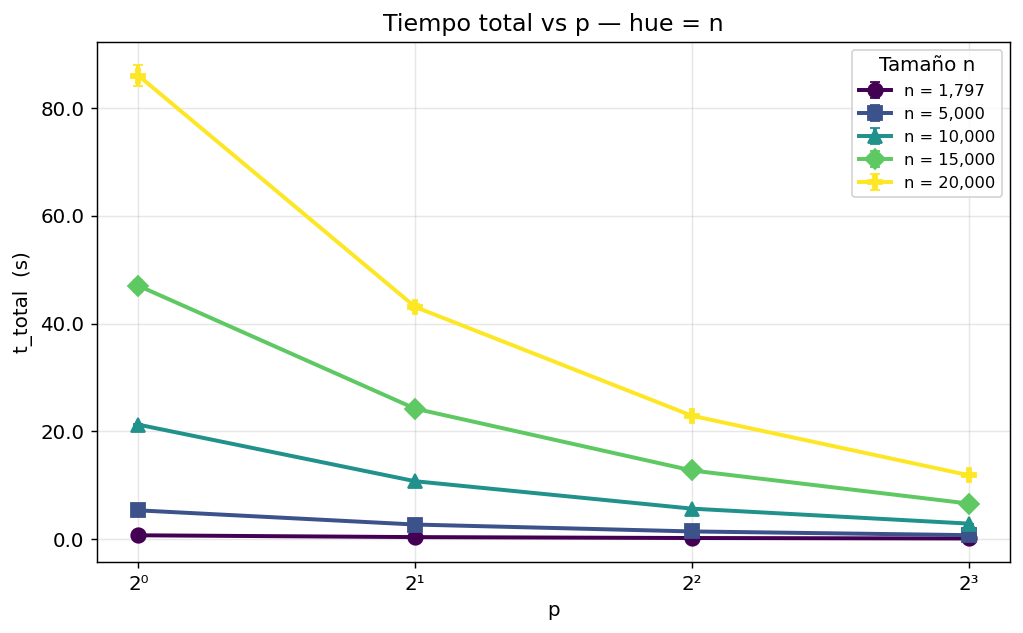

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))
for n_val in N_SIZES:
    sub = AGG[AGG.n==n_val].sort_values('p')
    if sub.empty: continue
    ax.errorbar(sub['p'], sub['t_total_mean'], yerr=sub['t_total_std'],
                fmt=f"{N_MARKERS[n_val]}-", color=N_COLORS[n_val],
                capsize=3, label=N_LABELS[n_val])

set_p_xticks(ax)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.set_xlabel('p')
ax.set_ylabel('t_total  (s)')
ax.set_title('Tiempo total vs p — hue = n')
ax.legend(fontsize=9, title='Tamaño n')
plt.tight_layout()
plt.savefig('fig_t_total_vs_p.pdf', bbox_inches='tight')
plt.show()

## 4. Ajuste teórico y p óptimo — solo N_MAX

Modelo:
$$T_{total}(p)=\underbrace{\frac{\alpha}{p}}_{T_{compute}}+\underbrace{\beta\, p}_{T_{comm}}$$

**¿Por qué β·p?** En V1 el bcast (pickle) envía X\_train completo a cada proceso: al aumentar p, Open MPI
necesita más rutas de comunicación → la latencia total crece aproximadamente lineal en p.
El modelo β·log₂(p) subestima β porque excluye p=1 del ajuste y sobreestima la curva al extrapolar,
haciendo que el cruce aparezca en p≈9 (dentro del rango medido), lo cual es incorrecto.

Derivando e igualando a cero:
$$\frac{dT}{dp}=-\frac{\alpha}{p^2}+\beta=0 \implies p^*=\sqrt{\frac{\alpha}{\beta}}$$

Se ajusta con los 4 puntos experimentales y se extrapola hasta p=128.

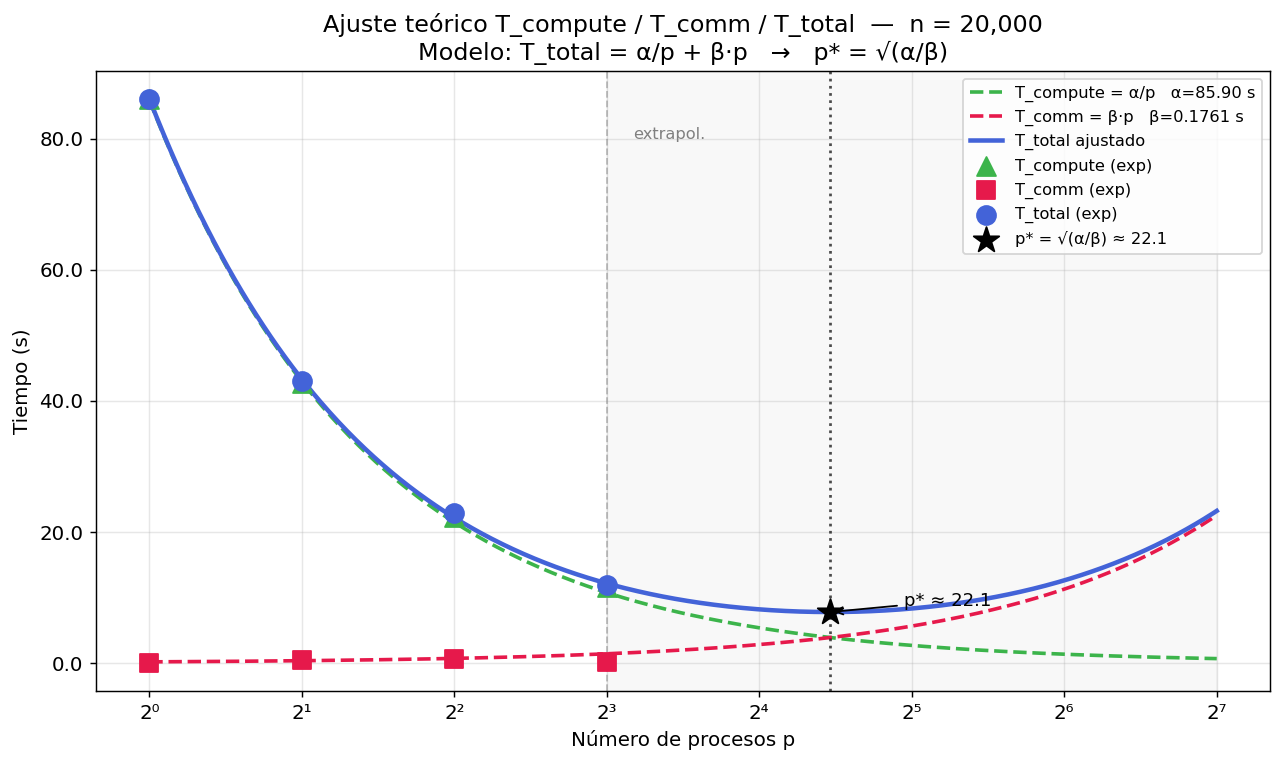

Parámetros ajustados (n=20,000):
  α = 85.9015 s   (T_compute = α/p)
  β = 0.176062 s  (T_comm = β·p)
  p* = √(α/β) = 22.09
  T_total(p*) = 7.78 s


In [65]:
sub_max = AGG[AGG.n==N_MAX].sort_values('p')

p_exp  = sub_max['p'].values.astype(float)
tc_exp = sub_max['t_compute_mean'].values
tm_exp = sub_max['t_comm_mean'].values
tt_exp = sub_max['t_total_mean'].values

# ── Modelos ──────────────────────────────────────────────────────────
# T_compute = α/p  (parallelismo perfecto)
# T_comm    = β·p  (overhead lineal con p — bcast a más destinos)
# T_total   = α/p + β·p  →  p* = sqrt(α/β)
def f_compute(p, alpha):        return alpha / p
def f_comm(p, beta):            return beta * p
def f_total(p, alpha, beta):    return f_compute(p, alpha) + f_comm(p, beta)

# Ajustes — TODOS los p incluidos (no excluir p=1)
(alpha,), _ = curve_fit(f_compute, p_exp, tc_exp, p0=[tc_exp[0]])
(beta,),  _ = curve_fit(f_comm,    p_exp, tm_exp, p0=[tm_exp.mean()])
# Ajuste conjunto T_total para la curva azul
(a_fit, b_fit), _ = curve_fit(f_total, p_exp, tt_exp,
                               p0=[alpha, beta], bounds=([0,0],[np.inf,np.inf]))

# p* analítico del ajuste conjunto
p_opt  = np.sqrt(a_fit / b_fit) if b_fit > 0 else None
p_fine = np.geomspace(1, 128, 600)  # extrapolar hasta 128

fig, ax = plt.subplots(figsize=(10, 6))

# ── Curvas ajustadas ────────────────────────────────────────────────
ax.plot(p_fine, f_compute(p_fine, a_fit),
        '--', color='#3cb44b', lw=2, label=f'T_compute = α/p   α={a_fit:.2f} s')
ax.plot(p_fine, f_comm(p_fine, b_fit),
        '--', color='#e6194b', lw=2, label=f'T_comm = β·p   β={b_fit:.4f} s')
ax.plot(p_fine, f_total(p_fine, a_fit, b_fit),
        '-',  color='#4363d8', lw=2.5, label='T_total ajustado')

# ── Puntos experimentales ───────────────────────────────────────────
ax.scatter(p_exp, tc_exp, color='#3cb44b', marker='^', s=110, zorder=6,
           label='T_compute (exp)')
ax.scatter(p_exp, tm_exp, color='#e6194b', marker='s', s=110, zorder=6,
           label='T_comm (exp)')
ax.scatter(p_exp, tt_exp, color='#4363d8', marker='o', s=110, zorder=6,
           label='T_total (exp)')

# ── p óptimo ────────────────────────────────────────────────────────
if p_opt is not None:
    t_at_popt = f_total(p_opt, a_fit, b_fit)
    ax.axvline(p_opt, color='k', linestyle=':', lw=1.5, alpha=0.7)
    ax.scatter([p_opt], [t_at_popt], color='k', marker='*', s=220,
               zorder=7, label=f'p* = √(α/β) ≈ {p_opt:.1f}')
    ax.annotate(f'p* ≈ {p_opt:.1f}',
                xy=(p_opt, t_at_popt),
                xytext=(p_opt * 1.4, t_at_popt * 1.12),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='k'))

# ── Región extrapolada (p > 8) ───────────────────────────────────────
ax.axvspan(8, 128, alpha=0.05, color='gray')
ax.axvline(8, color='gray', linestyle='--', lw=1, alpha=0.5)
ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
# Anotar al inicio de la región extrapolada
ax.text(9, tt_exp.max()*0.95, 'extrapol.', fontsize=9, color='gray', va='top')

# ── Ejes ─────────────────────────────────────────────────────────────
p_ticks = [1, 2, 4, 8, 16, 32, 64, 128]
set_p_xticks(ax, p_ticks)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.set_xlabel('Número de procesos p')
ax.set_ylabel('Tiempo (s)')
ax.set_title(
    f'Ajuste teórico T_compute / T_comm / T_total  —  n = {N_MAX:,}\n'
    f'Modelo: T_total = α/p + β·p   →   p* = √(α/β)'
)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('fig_crossover_popt.pdf', bbox_inches='tight')
plt.show()

print(f'Parámetros ajustados (n={N_MAX:,}):')
print(f'  α = {a_fit:.4f} s   (T_compute = α/p)')
print(f'  β = {b_fit:.6f} s  (T_comm = β·p)')
if p_opt:
    print(f'  p* = √(α/β) = {p_opt:.2f}')
    print(f'  T_total(p*) = {f_total(p_opt, a_fit, b_fit):.2f} s')

## 5. Desglose comunicación vs cómputo — solo N_MAX

Se muestra para el dataset más grande (`n = N_MAX`) el detalle de cada componente de tiempo.
La barra de **T_compute** permite ver cuánto mayor es el cómputo respecto a la comunicación
(granularidad G = T_compute / T_comm). Eje y en log para poder ver ambas escalas.

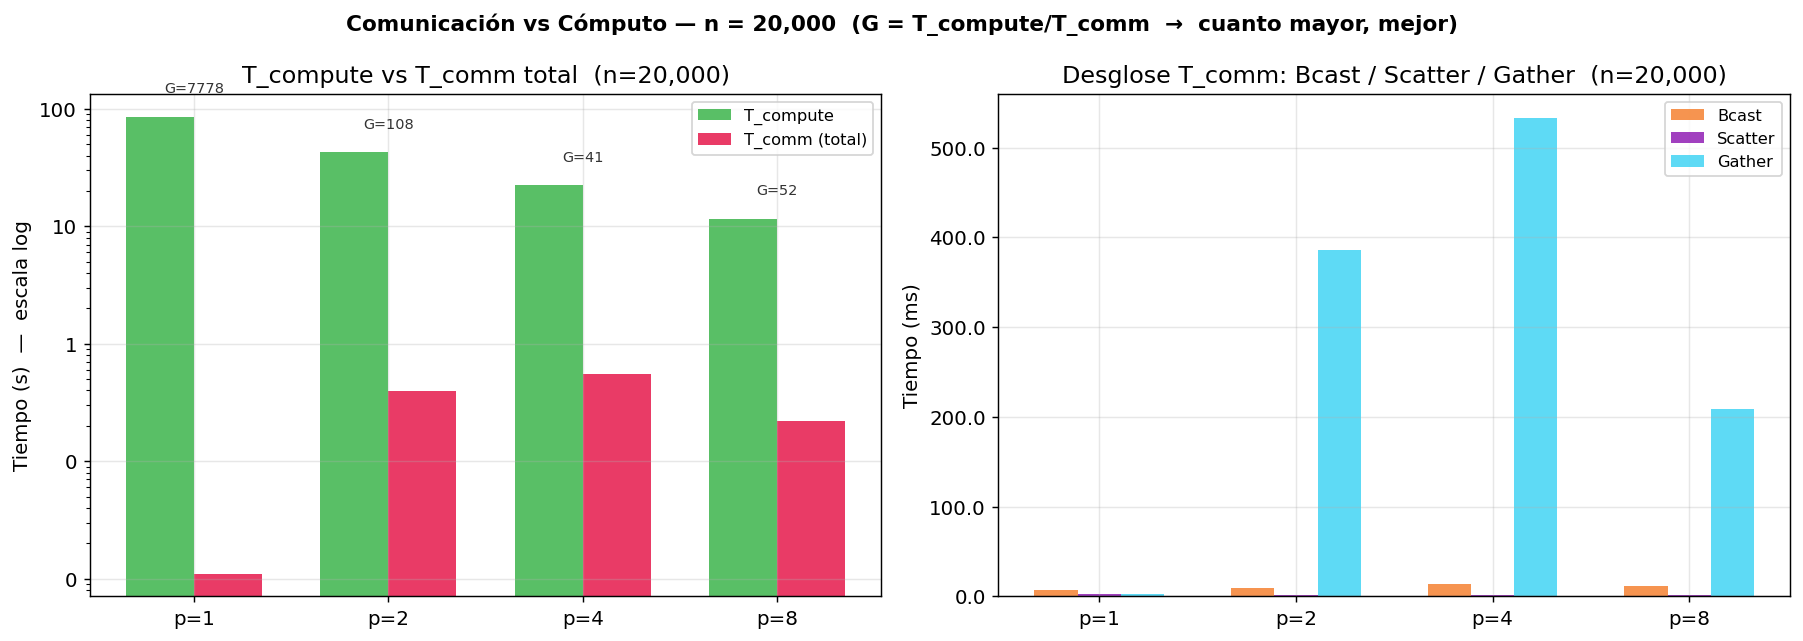

Granularidad G = T_compute / T_comm  (n=20,000):
  p= 1  G= 7777.6  t_compute=86032ms  t_comm=11ms
  p= 2  G=  107.7  t_compute=42694ms  t_comm=396ms
  p= 4  G=   40.7  t_compute=22340ms  t_comm=549ms
  p= 8  G=   52.4  t_compute=11627ms  t_comm=222ms


In [66]:
sub5 = AGG[AGG.n == N_MAX].sort_values('p')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: T_compute + T_comm total (log scale) ───────────
ax1 = axes[0]
x  = np.arange(len(sub5))
w  = 0.35
b1 = ax1.bar(x - w/2, sub5['t_compute_mean'], w,
             label='T_compute', color='#3cb44b', alpha=0.85)
b2 = ax1.bar(x + w/2, sub5['t_comm_mean'],    w,
             label='T_comm (total)', color='#e6194b', alpha=0.85)

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax1.set_xticks(x)
ax1.set_xticklabels([f'p={p}' for p in sub5['p']])
ax1.set_ylabel('Tiempo (s)  —  escala log')
ax1.set_title(f'T_compute vs T_comm total  (n={N_MAX:,})')
ax1.legend(fontsize=9)

# Anotar ratio G = T_compute / T_comm encima de cada par
for xi, (tc, tm) in enumerate(zip(sub5['t_compute_mean'], sub5['t_comm_mean'])):
    if tm > 0:
        ax1.text(xi, max(tc, tm) * 1.6, f'G={tc/tm:.0f}',
                 ha='center', fontsize=8, color='#333333')

# ── Panel derecho: desglose Bcast / Scatter / Gather (ms) ───────────
ax2 = axes[1]
w3  = 0.22
b_b = ax2.bar(x - w3,   sub5['t_bcast_mean']   * 1e3, w3,
              label='Bcast',   color='#f58231', alpha=0.85)
b_s = ax2.bar(x,         sub5['t_scatter_mean'] * 1e3, w3,
              label='Scatter', color='#911eb4', alpha=0.85)
b_g = ax2.bar(x + w3,   sub5['t_gather_mean']  * 1e3, w3,
              label='Gather',  color='#42d4f4', alpha=0.85)

ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax2.set_xticks(x)
ax2.set_xticklabels([f'p={p}' for p in sub5['p']])
ax2.set_ylabel('Tiempo (ms)')
ax2.set_title(f'Desglose T_comm: Bcast / Scatter / Gather  (n={N_MAX:,})')
ax2.legend(fontsize=9)

plt.suptitle(
    f'Comunicación vs Cómputo — n = {N_MAX:,}  '
    f'(G = T_compute/T_comm  →  cuanto mayor, mejor)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_comm_breakdown.pdf', bbox_inches='tight')
plt.show()

print(f'Granularidad G = T_compute / T_comm  (n={N_MAX:,}):')
for _, row in sub5.iterrows():
    g = row['t_compute_mean']/row['t_comm_mean'] if row['t_comm_mean']>0 else float('inf')
    print(f'  p={int(row["p"]):2d}  G={g:7.1f}  '
          f't_compute={row["t_compute_mean"]*1e3:.0f}ms  '
          f't_comm={row["t_comm_mean"]*1e3:.0f}ms')

## 6. FLOPs/s vs p — una línea por N
Eje y: GFLOP/s **lineal** (sin log). Línea punteada = escala ideal desde p=1.

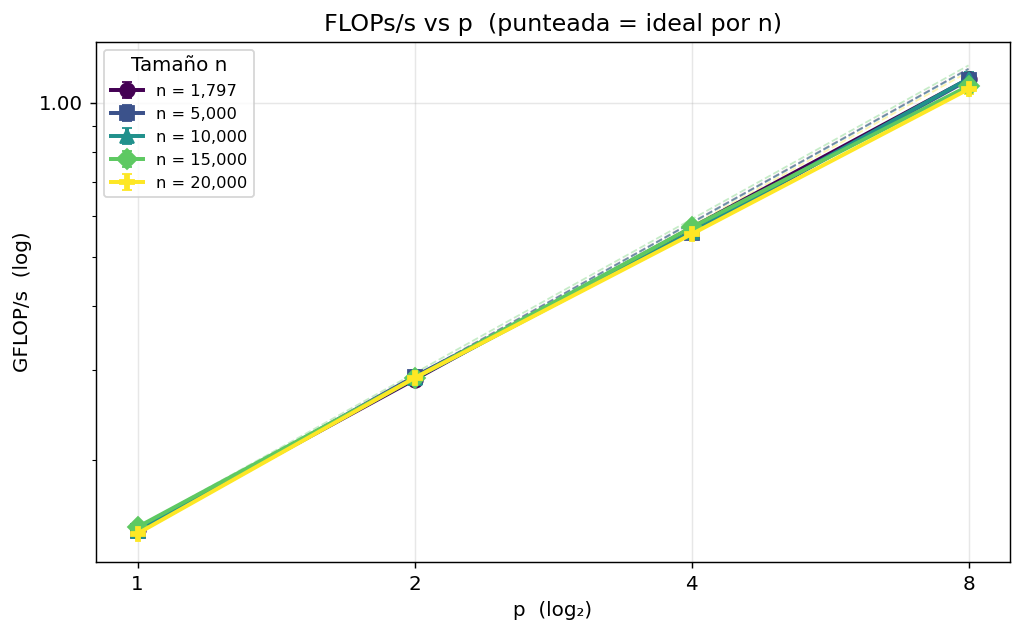

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
for n_val in N_SIZES:
    sub = AGG[AGG.n==n_val].sort_values('p')
    if sub.empty: continue
    fps1 = sub.loc[sub.p==1, 'fps_mean'].values
    if len(fps1):
        ax.plot(np.array(P_VALS, float), fps1[0]*np.array(P_VALS, float)/1e9,
                '--', color=N_COLORS[n_val], lw=1, alpha=0.35)
    ax.errorbar(sub['p'], sub['fps_mean']/1e9, yerr=sub['fps_std']/1e9,
                fmt=f"{N_MARKERS[n_val]}-", color=N_COLORS[n_val],
                capsize=3, label=N_LABELS[n_val])

ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(P_VALS); ax.set_xticklabels(P_VALS)
ax.set_xlabel('p  (log₂)'); ax.set_ylabel('GFLOP/s  (log)')
ax.set_title('FLOPs/s vs p  (punteada = ideal por n)')
ax.legend(fontsize=9, title='Tamaño n')
plt.tight_layout()
plt.savefig('fig_flops_vs_p.pdf', bbox_inches='tight')
plt.show()

## 7. Escalabilidad — t_compute vs n y Speedup vs n

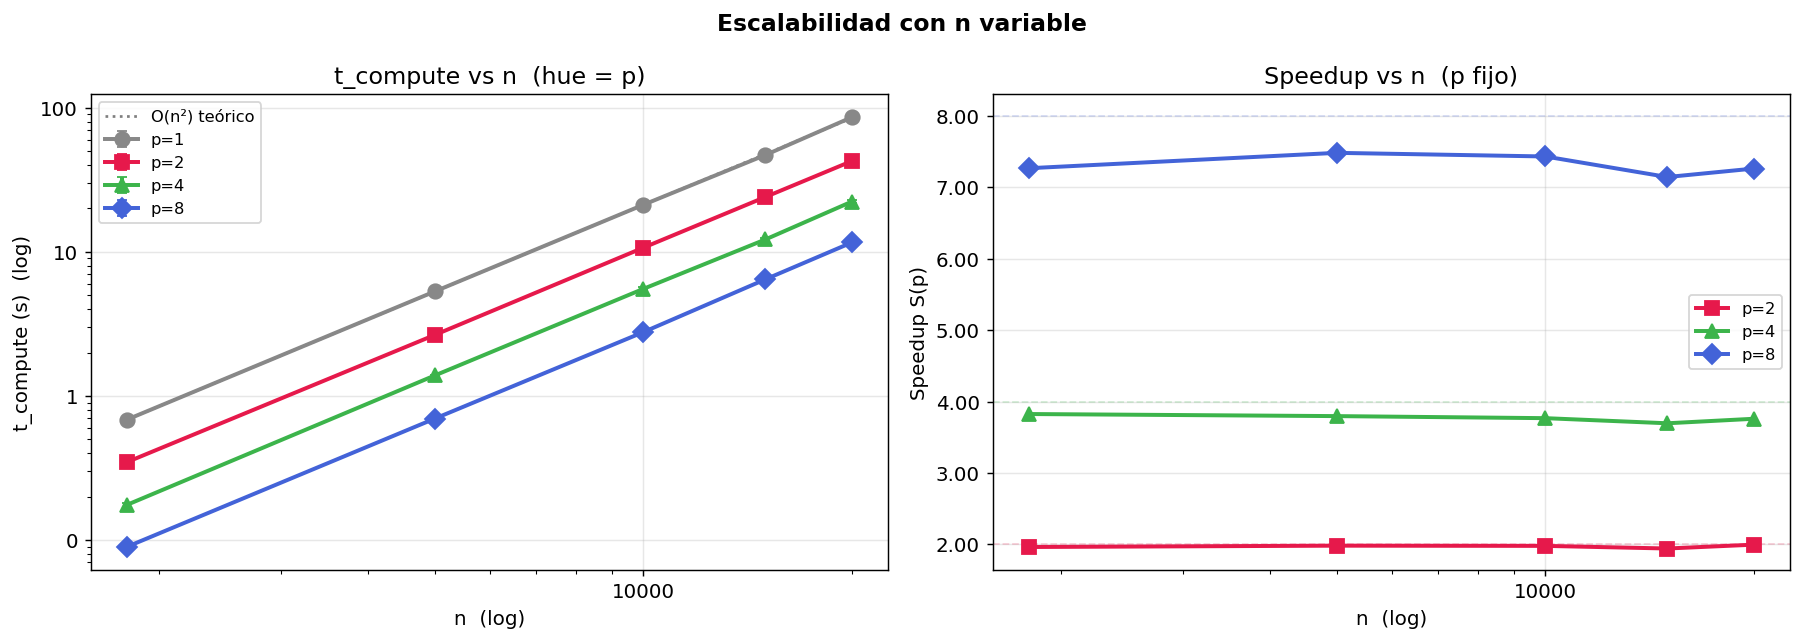

In [68]:
if len(N_SIZES) < 2:
    print('⚠ Solo hay un tamaño — corre con ALL_SIZES=1')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for p in P_VALS:
        sub = AGG[AGG.p==p].sort_values('n')
        if sub.empty: continue
        ax.errorbar(sub['n'], sub['t_compute_mean'], yerr=sub['t_compute_std'],
                    fmt=f"{P_MARKERS[p]}-", color=P_COLORS[p], capsize=3, label=f'p={p}')
    T0 = AGG.loc[(AGG.p==1)&(AGG.n==N_BASE),'t_compute_mean']
    if not T0.empty:
        C  = T0.values[0]/N_BASE**2
        ns = np.array(N_SIZES, dtype=float)
        ax.plot(ns, C*ns**2, 'k:', alpha=0.5, lw=1.5, label='O(n²) teórico')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel('n  (log)'); ax.set_ylabel('t_compute (s)  (log)')
    ax.set_title('t_compute vs n  (hue = p)'); ax.legend(fontsize=9)

    ax2 = axes[1]
    for p in [2,4,8]:
        ns_l, sp_l = [], []
        for n_val in N_SIZES:
            T1 = AGG.loc[(AGG.p==1)&(AGG.n==n_val),'t_total_mean']
            Tp = AGG.loc[(AGG.p==p)&(AGG.n==n_val),'t_total_mean']
            if T1.empty or Tp.empty: continue
            ns_l.append(n_val); sp_l.append(T1.values[0]/Tp.values[0])
        if ns_l:
            ax2.plot(ns_l, sp_l, f"{P_MARKERS[p]}-",
                     color=P_COLORS[p], label=f'p={p}')
            ax2.axhline(p, color=P_COLORS[p], linestyle='--', alpha=0.2, lw=1)
    ax2.set_xscale('log')
    ax2.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax2.set_xlabel('n  (log)'); ax2.set_ylabel('Speedup S(p)')
    ax2.set_title('Speedup vs n  (p fijo)'); ax2.legend(fontsize=9)

    plt.suptitle('Escalabilidad con n variable', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_escalabilidad.pdf', bbox_inches='tight')
    plt.show()

## 8. Ley de Amdahl — ajuste por N
$$S(p)=\frac{1}{(1-f)+f/p}$$
Ajuste no-lineal de `f` por mínimos cuadrados para cada n.

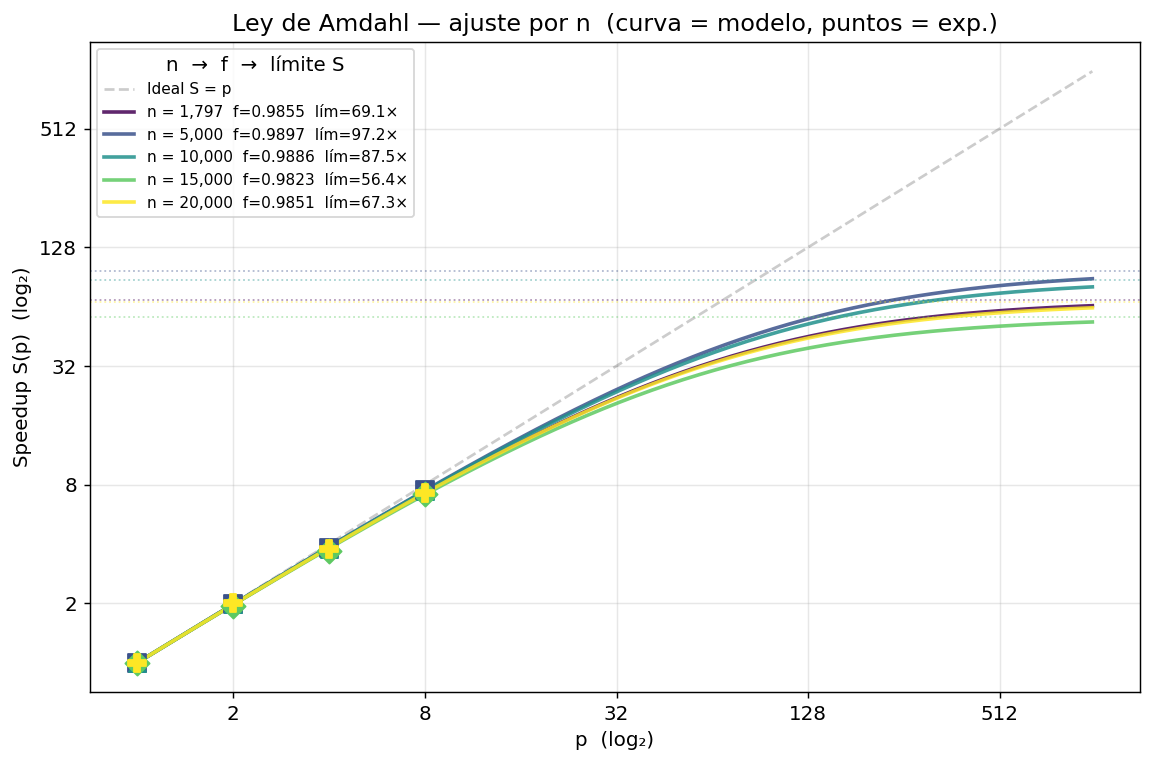


Resumen Amdahl:
       n    f ajust.     lím S→∞    S(p=4)    E(p=4)
----------------------------------------------------
   1,797      0.9855       69.10     3.825     0.956
   5,000      0.9897       97.17     3.796     0.949
  10,000      0.9886       87.55     3.768     0.942
  15,000      0.9823       56.44     3.696     0.924
  20,000      0.9851       67.28     3.759     0.940


In [69]:
def amdahl(p, f):
    return 1.0 / ((1 - f) + f / p)

fig, ax = plt.subplots(figsize=(9, 6))
p_range = np.logspace(0, 3, 300)
ax.plot(p_range, p_range, 'k--', alpha=0.2, lw=1.5, label='Ideal S = p')

f_table = {}
for n_val in N_SIZES:
    sub = SP[SP.n==n_val].sort_values('p')
    if sub.empty or len(sub) < 2: continue
    p_exp = sub['p'].values.astype(float)
    s_exp = sub['speedup'].values
    try:
        (f_fit,), _ = curve_fit(amdahl, p_exp, s_exp,
                                 p0=[0.9], bounds=(0.01, 0.9999))
    except Exception:
        f_fit = (1/s_exp[-1]-1)/(1/p_exp[-1]-1)
    f_table[n_val] = f_fit

    # Curva teórica ajustada
    ax.plot(p_range, amdahl(p_range, f_fit),
            '-', color=N_COLORS[n_val], lw=2, alpha=0.85,
            label=f'{N_LABELS[n_val]}  f={f_fit:.4f}  lím={1/(1-f_fit):.1f}×')
    ax.axhline(1/(1-f_fit), color=N_COLORS[n_val],
               linestyle=':', lw=1, alpha=0.4)
    # Puntos experimentales encima
    ax.scatter(p_exp, s_exp,
               color=N_COLORS[n_val], marker=N_MARKERS[n_val], s=90, zorder=5)

ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel('p  (log₂)'); ax.set_ylabel('Speedup S(p)  (log₂)')
ax.set_title('Ley de Amdahl — ajuste por n  (curva = modelo, puntos = exp.)')
ax.legend(fontsize=8.5, title='n  →  f  →  límite S')
plt.tight_layout()
plt.savefig('fig_amdahl.pdf', bbox_inches='tight')
plt.show()

print('\nResumen Amdahl:')
print(f'{"n":>8}  {"f ajust.":>10}  {"lím S→∞":>10}  {"S(p=4)":>8}  {"E(p=4)":>8}')
print('-'*52)
for n_val, f in f_table.items():
    s4 = SP.loc[(SP.n==n_val)&(SP.p==4),'speedup']
    e4 = SP.loc[(SP.n==n_val)&(SP.p==4),'efficiency']
    s4v = s4.values[0] if not s4.empty else float('nan')
    e4v = e4.values[0] if not e4.empty else float('nan')
    print(f'{n_val:>8,}  {f:>10.4f}  {1/(1-f):>10.2f}  {s4v:>8.3f}  {e4v:>8.3f}')

## 9. Accuracy vs p

In [70]:
acc_piv = AGG[AGG.n==N_BASE][['p','accuracy_mean']].set_index('p')
print(f'Accuracy por p (n={N_BASE}):')
print(acc_piv.round(4).to_string())
print(f'\nVariación máxima: {acc_piv["accuracy_mean"].max()-acc_piv["accuracy_mean"].min():.6f}')

Accuracy por p (n=1797):
   accuracy_mean
p               
1         0.9861
2         0.9861
4         0.9861
8         0.9861

Variación máxima: 0.000000


## 10. Tabla resumen
**Granularidad** = ratio cómputo/comunicación: $G = T_{compute} / T_{comm}$  
Un valor alto → cómputo domina → el overhead de comunicación es despreciable.

In [71]:
rows = []
for n_val in N_SIZES:
    T1_total   = AGG.loc[(AGG.p==1)&(AGG.n==n_val),'t_total_mean']
    T1_compute = AGG.loc[(AGG.p==1)&(AGG.n==n_val),'t_compute_mean']
    if T1_total.empty: continue
    T1t = T1_total.values[0]
    T1c = T1_compute.values[0]

    for p in P_VALS:
        r = AGG.loc[(AGG.p==p)&(AGG.n==n_val)]
        if r.empty: continue
        r = r.iloc[0]

        tc   = r['t_compute_mean']
        tm   = r['t_comm_mean']
        tt   = r['t_total_mean']
        S    = T1t / tt
        E    = S / p
        G    = tc / tm if tm > 0 else float('inf')
        gfps = r['fps_mean'] / 1e9

        rows.append({
            'n':              n_val,
            'p':              p,
            'T_total (ms)':   round(tt   * 1e3, 2),
            'T_comm (ms)':    round(tm   * 1e3, 3),
            'T_compute (ms)': round(tc   * 1e3, 2),
            'Speedup S':      round(S,           4),
            'Eficiencia E':   round(E,           4),
            'Granularidad G': round(G,           2),
            'GFLOP/s':        round(gfps,        4),
        })

TABLA = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_rows', 100)
TABLA

,n,p,T_total (ms),T_comm (ms),T_compute (ms),Speedup S,Eficiencia E,Granularidad G,GFLOP/s
0,1797,1,686.0200,0.9270,685.0900,1.0000,1.0000,739.2000,0.1458
1,1797,2,349.2800,1.8850,347.4000,1.9641,0.9820,184.2700,0.2874
2,1797,4,179.3300,3.8280,175.5000,3.8255,0.9564,45.8400,0.5692
3,1797,8,94.4100,4.6320,89.7800,7.2664,0.9083,19.3800,1.1128
4,5000,1,"5,317.0100",2.5960,"5,314.4200",1.0000,1.0000,"2,046.8900",0.1453
5,5000,2,"2,681.6100",29.1050,"2,652.5000",1.9828,0.9914,91.1400,0.2913
6,5000,4,"1,400.5600",12.9810,"1,387.5800",3.7964,0.9491,106.9000,0.5564
7,5000,8,710.6700,14.2220,696.4500,7.4817,0.9352,48.9700,1.1088
8,10000,1,"21,230.1300",5.0690,"21,225.0600",1.0000,1.0000,"4,187.2300",0.1455
9,10000,2,"10,723.5400",31.0490,"10,692.4900",1.9798,0.9899,344.3700,0.2888


In [72]:
# Exportar a CSV y mostrar como tabla formateada
TABLA.to_csv('tabla_resumen.csv', index=False)
print('Guardada en tabla_resumen.csv')
print()
print(TABLA.to_string(index=False))

Guardada en tabla_resumen.csv

    n  p  T_total (ms)  T_comm (ms)  T_compute (ms)  Speedup S  Eficiencia E  Granularidad G  GFLOP/s
 1797  1      686.0200       0.9270        685.0900     1.0000        1.0000        739.2000   0.1458
 1797  2      349.2800       1.8850        347.4000     1.9641        0.9820        184.2700   0.2874
 1797  4      179.3300       3.8280        175.5000     3.8255        0.9564         45.8400   0.5692
 1797  8       94.4100       4.6320         89.7800     7.2664        0.9083         19.3800   1.1128
 5000  1    5,317.0100       2.5960      5,314.4200     1.0000        1.0000      2,046.8900   0.1453
 5000  2    2,681.6100      29.1050      2,652.5000     1.9828        0.9914         91.1400   0.2913
 5000  4    1,400.5600      12.9810      1,387.5800     3.7964        0.9491        106.9000   0.5564
 5000  8      710.6700      14.2220        696.4500     7.4817        0.9352         48.9700   1.1088
10000  1   21,230.1300       5.0690     21,225.0600

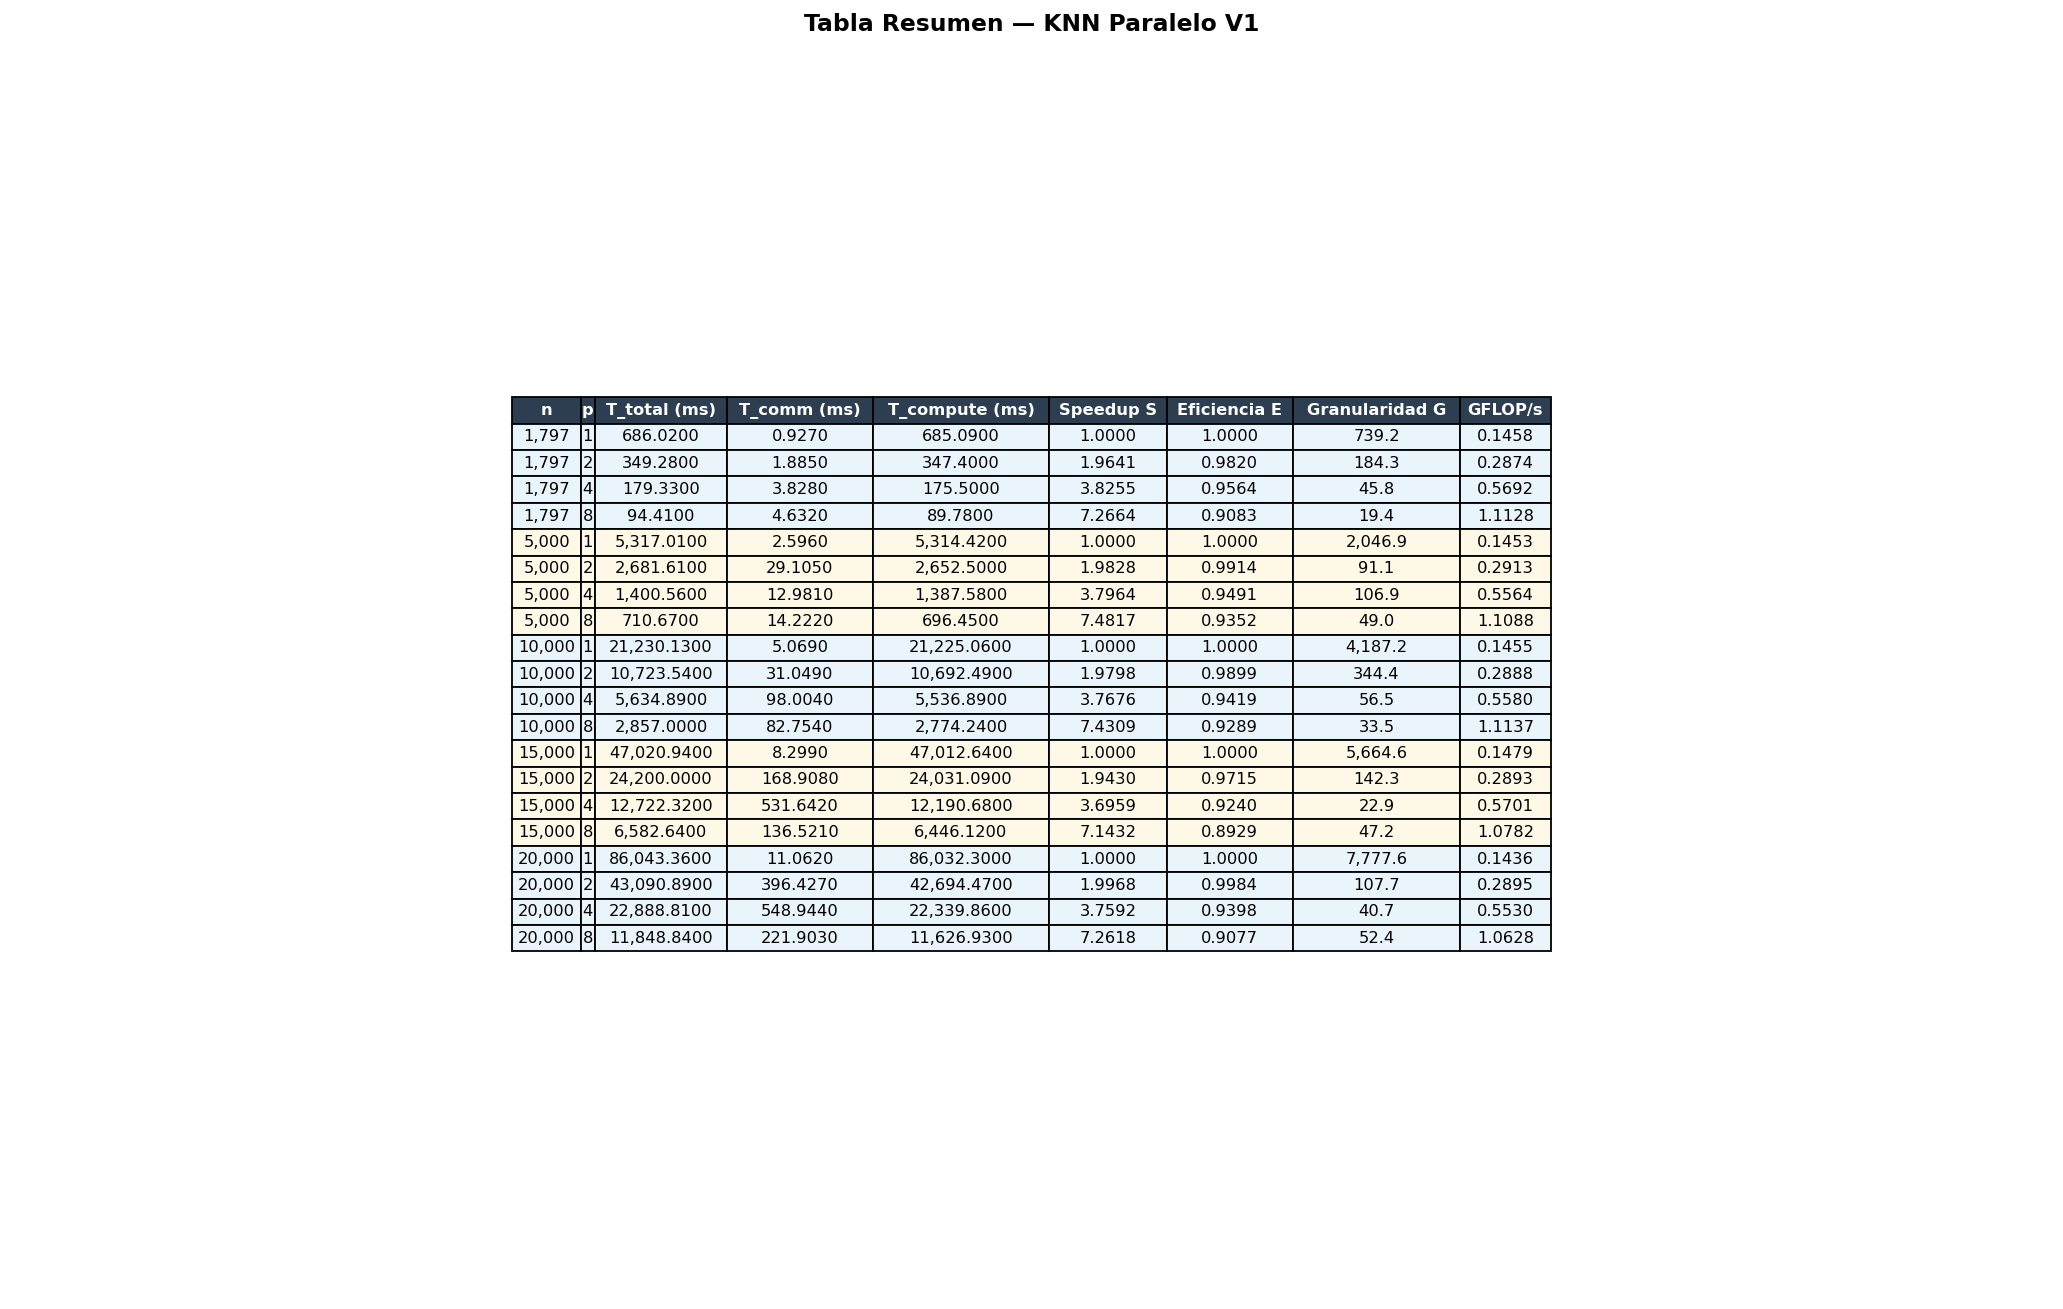

In [73]:
# Visualización de la tabla como figura
fig, ax = plt.subplots(figsize=(16, 0.45*len(TABLA)+1.2))
ax.axis('off')

cols = TABLA.columns.tolist()
vals = []
for _, row in TABLA.iterrows():
    fmtd = []
    for c, v in zip(cols, row):
        if c in ('n','p'):           fmtd.append(f'{int(v):,}')
        elif c == 'Granularidad G':  fmtd.append(f'{v:,.1f}' if v < 1e6 else '∞')
        else:                        fmtd.append(f'{v:,.4f}')
    vals.append(fmtd)

# Color alternado por n
row_colors = []
color_map = {n: ('#eaf4fb' if i%2==0 else '#fef9e7') for i,n in enumerate(N_SIZES)}
for _, row in TABLA.iterrows():
    row_colors.append([color_map[row['n']]]*len(cols))

tbl = ax.table(
    cellText=vals,
    colLabels=cols,
    cellColours=row_colors,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(cols))))

# Header más oscuro
for j in range(len(cols)):
    tbl[(0,j)].set_facecolor('#2c3e50')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')

plt.title('Tabla Resumen — KNN Paralelo V1', fontsize=13,
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('tabla_resumen.pdf', bbox_inches='tight', dpi=150)
plt.show()